# Cài đặt các Thư viện sử dụng

In [1]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import joblib
from underthesea import word_tokenize
import os

In [2]:
import warnings
warnings.filterwarnings("ignore")

# Cài đặt hiển thị dataFrame

In [3]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

# Đọc dữ liệu


- vn_news_223_tdlfr.csv là file chứa news cần xử lý
- vietnamese-stopwords.txt chứa các stop word cần xử lý

In [4]:
file = os.path.join("../../Data_Train", "English.csv")
data_df = pd.read_csv(file, encoding = 'utf-8')

# Khám phá dữ liệu

## Mẫu dữ liệu

In [5]:
data_df.sample(1)

,title,text,label
14221,U.S. marine accused of drunk driving after Japanese man dies in crash,TOKYO (Reuters) - A Japanese man was killed in a truck collision involving a 21-year-old U.S. marine who was well over the legal alcohol limit for driving police said of a case that was likely to stoke resentment over the U.S. military presence on the southern island of Okinawa. In response to the Sunday s fatal accident U.S. forces in Japan banned until further notice all personnel in the country from drinking of alcohol. The Defence and Foreign Ministries have lodged a stern representation to the U.S. forces in Japan and the U.S. embassy in Japan asking for the enforcement of discipline prevention of recurrence and sincere response to the bereaved Japanese Chief Cabinet Secretary Yoshihide Suga told a regular news conference on Monday. U.S. Ambassador to Japan William Hagerty expressed his condolences and offered an apology Suga said. The accident occurred at an intersection in the city of Naha early Sunday morning. The marine was driving a military truck and the 61-year-old crash victim was in a light truck. The Japanese man was later pronounced dead while the U.S. serviceman who was arrested for the fatal accident and driving under the influence of alcohol suffered scratches a police official in Naha said. The official said a breath test showed the marine was as much as three times over the legal limit for alcohol. When our service members fail to live up to the high standards we set for them it damages the bonds between bases and local communities and make it harder for us to accomplish our mission a statement from the U.S. forces in Japan said. Last year Japanese Prime Minister Shinzo Abe protested to then-U.S. President Barack Obama about the killing of a young woman in Okinawa for which a U.S. base worker had been charged. Obama who was visiting Japan for a Group of Seven summit expressed deepest regrets. The case is under trial. Residents in Okinawa a reluctant host to the bulk of U.S. bases in Japan believe that they shoulder an unfair burden in supporting the U.S. military presence in Japan.,0


## Xem thông tin

In [6]:
data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39000 entries, 0 to 38999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   39000 non-null  object
 1   text    39000 non-null  object
 2   label   39000 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 914.2+ KB


## Xem mô tả

In [7]:
data_df.describe().round(1)

,label
count,39000.0
mean,0.5
std,0.5
min,0.0
25%,0.0
50%,0.5
75%,1.0
max,1.0


## Xem số dòng và số cột của dữ liệu

In [8]:
num_rows=data_df.shape[0]
num_cols=data_df.shape[1]
print(num_rows)
print(num_cols)

39000
3


## ý nghĩa của các dòng

### Kiểm tra dữ liệu có bị lặp ?

In [9]:
dup=data_df.index.duplicated().sum()
dup

0

### ý nghĩa các cột

- text: nội dung của tin tức
- domain: đường dẫn đến trang web chứa tin tức 
- label: nhãn phân biệt tin giả hay tin thật

### Dữ liệu có bị thiếu không?

In [10]:
data_df['title'].isnull().sum()

0

In [11]:
data_df['text'].isnull().sum()

0

In [12]:
data_df['label'].isnull().sum()

0

### Mỗi cột hiện đang có kiểu dữ liệu gì? Có cột nào có kiểu dữ liệu chưa phù hợp để có thể xử lý tiếp không?

In [13]:
data_df.dtypes

title    object
text     object
label     int64
dtype: object

#### Cột có dtype là object nghĩa là sao?

- Trong Pandas, kiểu dữ liệu object thường ám chỉ chuỗi, nhưng thật ra kiểu dữ liệu object có thể chứa một đối tượng bất kỳ trong Python (vì thật ra ở bên dưới kiểu dữ liệu object chứa địa chỉ).
- Nếu một cột trong dataframe có dtype là object thì có thể các phần tử trong cột này sẽ có kiểu dữ liệu khác nhau
- Để biết được kiểu dữ liệu thật sự của các phần tử trong cột này thì ta phải truy xuất vào từng phần tử. Ta muốn xem thử trong nội bộ mỗi cột này có các kiểu dữ liệu nào

In [14]:
def open_object_dtype(s):
    dtypes = set()
    s=s.apply(type)
    dtypes.update(s.unique().tolist())
    return dtypes

In [15]:
open_object_dtype(data_df['title'])

{str}

In [16]:
open_object_dtype(data_df['text'])

{str}

In [17]:
open_object_dtype(data_df['label'])

{int}

In [18]:
data_df.isnull().sum()

title    0
text     0
label    0
dtype: int64

#### Kiểm tra phân bố các class có chênh lệch không?

Xem phân bố dữ liệu

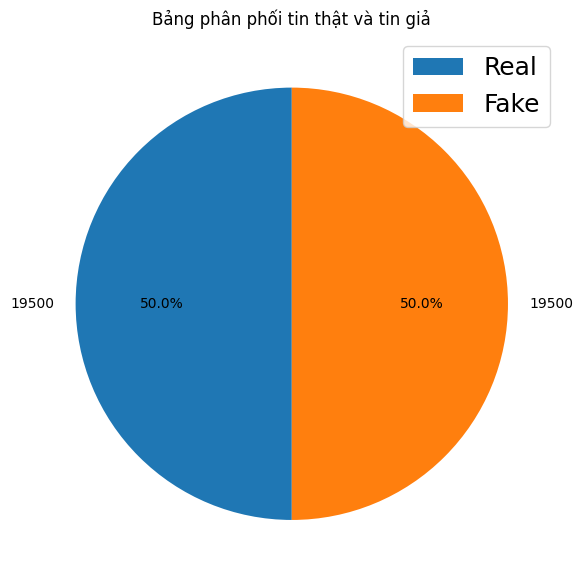

In [19]:
# data quantity chart
def quantity_chart():
    counts_df1 = data_df['label'].value_counts()

    plt.figure(figsize=(6, 6))

    plt.pie(counts_df1, labels=counts_df1, autopct='%1.1f%%', startangle=90)
    plt.title('Bảng phân phối tin thật và tin giả')

    labels = ['Real' if label == 0 else 'Fake' for label in counts_df1.index]
    plt.legend(labels=labels, loc="best", fontsize=18)  # Tăng kích thước nhãn trong chú thích
    plt.tight_layout()
    plt.show()
quantity_chart()

#### Các thông tin thống kê

##### Chiều dài trung bình mỗi record là bao nhiêu?

In [20]:
len_sum=0
for i in data_df['text']:
    len_sum+=len(i)
len_avg=len_sum/data_df['text'].count()
len_avg

2434.940871794872

##### Record dài nhất là bao nhiêu?

In [21]:
max_len=0
for i in data_df['text']:
    if len(i)>max_len:
        max_len=len(i)
max_len

49071

##### Record ngắn nhất là bao nhiêu?

In [22]:
min_len=len(data_df['text'][0])
for i in data_df['text']:
    if len(i)<min_len:
        min_len=len(i)
min_len

107

### Tiền xử lí văn bản

#### Loại bỏ các đường link và các dấu câu, lowercase

In [23]:
import nltk
from nltk.corpus import stopwords

# Tải stopwords từ NLTK nếu chưa tải
# nltk.download('stopwords')

# Sử dụng danh sách từ dừng (stopwords) của tiếng Anh từ NLTK
stopword_list = list(stopwords.words('english'))
stopwords = [word for word in stopword_list if word.strip() != '']


In [24]:
import string
def wordopt(text):
    text=re.sub("Reuters"," ",text)

    update_text =""

    text = text.lower()

    text=re.sub("reuters"," ",text)
    
    #simplifying text
    text=re.sub(r"i'm","i am",text)
    text=re.sub(r"he's","he is",text)
    text=re.sub(r"she's","she is",text)
    text=re.sub(r"that's","that is",text)
    text=re.sub(r"what's","what is",text)
    text=re.sub(r"where's","where is",text)
    text=re.sub(r"\'ll"," will",text)
    text=re.sub(r"\'ve"," have",text)
    text=re.sub(r"\'re"," are",text)
    text=re.sub(r"\'d"," would",text)
    text=re.sub(r"won't","will not",text)
    text=re.sub(r"can't","cannot",text)


    text=re.sub(r"[-()\"#!@$%^&*{}?.,:]"," ",text)
    text=re.sub(r"\s+"," ",text)

    text = re.sub('\[.*?\]', '', text)
    text = re.sub("\\W", " ", text)
    text = re.sub('https?://\S+|www\.\S+', '', text)
    text = re.sub('<.*?>+', '', text)
    text = re.sub('[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub('\n', '', text)
    text = re.sub('\w*\d\w*', '', text)

    for word in text.split():
        if word not in stopwords:
            update_text+=word+" "
    
    return update_text.strip()


In [25]:
data_df['article'] = ' |title| '+ data_df["title"] +' |text| '+  data_df["text"] 

In [26]:
data_df.head(1)

title  \
0  As U.S. budget fight looms Republicans flip their fiscal script   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                

In [27]:
data_df['Compound_Content_SW'] = data_df['article'].apply(wordopt)

In [28]:
data_df.head(1)

title  \
0  As U.S. budget fight looms Republicans flip their fiscal script   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                

# Vector hóa

#### Tokenizer

In [29]:
def tokenize(sentence):
    return word_tokenize(sentence, format = 'word')

### Mô hình hóa

- Chuyển đoạn văn tiếng Việt về vector, sử dụng CountVectorizer của sklearn
- với các tham số là danh sách stopwords tiếng Việt
- và tokenizer tách từ tiếng Việt

In [30]:
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

Chia tập dữ liệu thành 2 tập

- Tập train: 75%
- Tập test: 25%


In [31]:
X = data_df["Compound_Content_SW"]
y = data_df["label"]
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.25,
                                                   random_state=30)

In [32]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier

## CountVectorizer

In [33]:
model_vector_CV = os.path.join("../../Model/English/CV", "English_vectorizer_CV.joblib")
model_DTC_CV = os.path.join("../../Model/English/CV", "English_DTC_model_CV.joblib")
model_NB_CV = os.path.join("../../Model/English/CV", "English_NB_model_CV.joblib")
model_RFC_CV = os.path.join("../../Model/English/CV", "English_RFC_model_CV.joblib")


In [34]:
from sklearn.feature_extraction.text import CountVectorizer

In [36]:
vectorizerCV = CountVectorizer(
    stop_words = stopwords,
    tokenizer = tokenize,
)

In [37]:
Xv_trainCV = vectorizerCV.fit_transform(X_train)
Xv_testCV = vectorizerCV.transform(X_test)

In [38]:
joblib.dump(vectorizerCV, model_vector_CV)

['../../Model/English/CV\\English_vectorizer_CV.joblib']

### DecisionTreeClassifier

In [39]:
dtc_cv = DecisionTreeClassifier()
dtc_cv.fit(Xv_trainCV,y_train)

DecisionTreeClassifier()

In [40]:
pred_dt_cv = dtc_cv.predict(Xv_testCV)
print(dtc_cv.score(Xv_testCV, y_test))
print(classification_report(y_true=y_test, y_pred=pred_dt_cv))
#save model Decision Tree
joblib.dump(dtc_cv, model_DTC_CV)

0.9552820512820512
              precision    recall  f1-score   support

           0       0.96      0.95      0.96      4879
           1       0.95      0.96      0.96      4871

    accuracy                           0.96      9750
   macro avg       0.96      0.96      0.96      9750
weighted avg       0.96      0.96      0.96      9750



['../../Model/English/CV\\English_DTC_model_CV.joblib']

### Naive Bayes

In [41]:
nb_cv = MultinomialNB()
nb_cv.fit(Xv_trainCV,y_train)

MultinomialNB()

In [42]:
pred_np_cv = nb_cv.predict(Xv_testCV)
print(nb_cv.score(Xv_testCV, y_test))
print(classification_report(y_true=y_test, y_pred=pred_np_cv))
#save model Naive Bayes
joblib.dump(nb_cv, model_NB_CV)

0.9506666666666667
              precision    recall  f1-score   support

           0       0.95      0.95      0.95      4879
           1       0.95      0.95      0.95      4871

    accuracy                           0.95      9750
   macro avg       0.95      0.95      0.95      9750
weighted avg       0.95      0.95      0.95      9750



['../../Model/English/CV\\English_NB_model_CV.joblib']

### RandomForest

In [43]:
rfc_cv = RandomForestClassifier()

In [44]:
rfc_cv.fit(Xv_trainCV,y_train)

RandomForestClassifier()

In [45]:
pred_rfc_cv = rfc_cv.predict(Xv_testCV)
print(rfc_cv.score(Xv_testCV, y_test))
print(classification_report(y_true=y_test, y_pred=pred_rfc_cv))
#save model Naive Bayes
joblib.dump(rfc_cv, model_RFC_CV)

0.9825641025641025
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      4879
           1       0.98      0.98      0.98      4871

    accuracy                           0.98      9750
   macro avg       0.98      0.98      0.98      9750
weighted avg       0.98      0.98      0.98      9750



['../../Model/English/CV\\English_RFC_model_CV.joblib']

## TfidfVectorizer

In [46]:
model_vector_TF = os.path.join("../../Model/English/TF", "English_vectorizer_TF.joblib")
model_DTC_TF = os.path.join("../../Model/English/TF", "English_DTC_model_TF.joblib")
model_NB_TF = os.path.join("../../Model/English/TF", "English_NB_model_TF.joblib")
model_RFC_TF = os.path.join("../../Model/English/TF", "English_RFC_model_TF.joblib")


In [47]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [48]:
vectorizerTF = TfidfVectorizer(stop_words=stopwords)

In [49]:
Xv_trainTF = vectorizerTF.fit_transform(X_train)
Xv_testTF = vectorizerTF.transform(X_test)

In [50]:
joblib.dump(vectorizerTF, model_vector_TF)

['../../Model/English/TF\\English_vectorizer_TF.joblib']

### DecisionTreeClassifier

In [51]:
dtc_tf = DecisionTreeClassifier()
dtc_tf.fit(Xv_trainTF,y_train)

DecisionTreeClassifier()

In [52]:
pred_dtc_tf = dtc_tf.predict(Xv_testTF)
print(dtc_tf.score(Xv_testTF, y_test))
print(classification_report(y_true=y_test, y_pred=pred_dtc_tf))
#save model Decision Tree
joblib.dump(dtc_tf, model_DTC_TF)

0.9515897435897436
              precision    recall  f1-score   support

           0       0.96      0.94      0.95      4879
           1       0.95      0.96      0.95      4871

    accuracy                           0.95      9750
   macro avg       0.95      0.95      0.95      9750
weighted avg       0.95      0.95      0.95      9750



['../../Model/English/TF\\English_DTC_model_TF.joblib']

### Navie bayes

In [53]:
nb_tf = MultinomialNB()
nb_tf.fit(Xv_trainTF,y_train)

MultinomialNB()

In [54]:
pred_nb_tf = nb_tf.predict(Xv_testTF)
print(nb_tf.score(Xv_testTF, y_test))
print(classification_report(y_true=y_test, y_pred=pred_nb_tf))
#save model Naive Bayes
joblib.dump(nb_tf, model_NB_TF)

0.9381538461538461
              precision    recall  f1-score   support

           0       0.94      0.93      0.94      4879
           1       0.94      0.94      0.94      4871

    accuracy                           0.94      9750
   macro avg       0.94      0.94      0.94      9750
weighted avg       0.94      0.94      0.94      9750



['../../Model/English/TF\\English_NB_model_TF.joblib']

### RandomForest

In [55]:
rfc_tf = RandomForestClassifier()

In [56]:
rfc_tf.fit(Xv_trainTF,y_train)

RandomForestClassifier()

In [57]:
pred_rfc_tf = rfc_tf.predict(Xv_testTF)
print(rfc_tf.score(Xv_testTF, y_test))
print(classification_report(y_true=y_test, y_pred=pred_rfc_tf))
#save model Naive Bayes
joblib.dump(rfc_tf, model_RFC_TF)

0.9829743589743589
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      4879
           1       0.98      0.98      0.98      4871

    accuracy                           0.98      9750
   macro avg       0.98      0.98      0.98      9750
weighted avg       0.98      0.98      0.98      9750



['../../Model/English/TF\\English_RFC_model_TF.joblib']